***All necessary imports***

In [31]:
import pandas as pd
import sys
import os

%reload_ext autoreload
%autoreload 2
%matplotlib inline
modules_path = os.path.abspath("../modules")
if modules_path not in sys.path:
    sys.path.append(modules_path)
from helper_functions import HelperFunctions

***Create dataframe and remove duplicates***

In [32]:
bank_df = pd.read_csv('../csv/bank-additional-full.csv', sep=';')
bank_df = bank_df[~bank_df.duplicated()]

***Create ydata report and show dataframe info***

In [33]:
HelperFunctions.write_ydata_report_to_file(bank_df, "../html/ydata_report_initial.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

***[ydata initial report can be found here](https://reserford1991.github.io/bank-marketing-dataset-project/html/ydata_report_initial.html)***

In [34]:
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [35]:
bank_df.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

In [36]:
bank_df.isnull().values.any()

False

Let's transform strring columns into category columns

In [48]:
bank_df = HelperFunctions.transform_string_into_category_type(bank_df, ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'y'])

bank_df.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             41176 non-null  int64   
 1   job             41176 non-null  category
 2   marital         41176 non-null  category
 3   education       41176 non-null  category
 4   default         41176 non-null  category
 5   housing         41176 non-null  category
 6   loan            41176 non-null  category
 7   contact         41176 non-null  category
 8   month           41176 non-null  category
 9   day_of_week     41176 non-null  category
 10  duration        41176 non-null  int64   
 11  campaign        41176 non-null  int64   
 12  pdays           41176 non-null  int64   
 13  previous        41176 non-null  int64   
 14  poutcome        41176 non-null  object  
 15  emp.var.rate    41176 non-null  float64 
 16  cons.price.idx  41176 non-null  float64 
 17  cons.conf.idx   4

***As we can see, there are 20 feature columns and one target column - y.***

***Dataset has no null values in columns.***

***There are 10 categorical columns and 10 numeric columns.***

***Let's investigate each of those columns***

***1. `age` column analysis***

count    41176.00000
mean        40.02380
std         10.42068
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64
Number of null values: 0


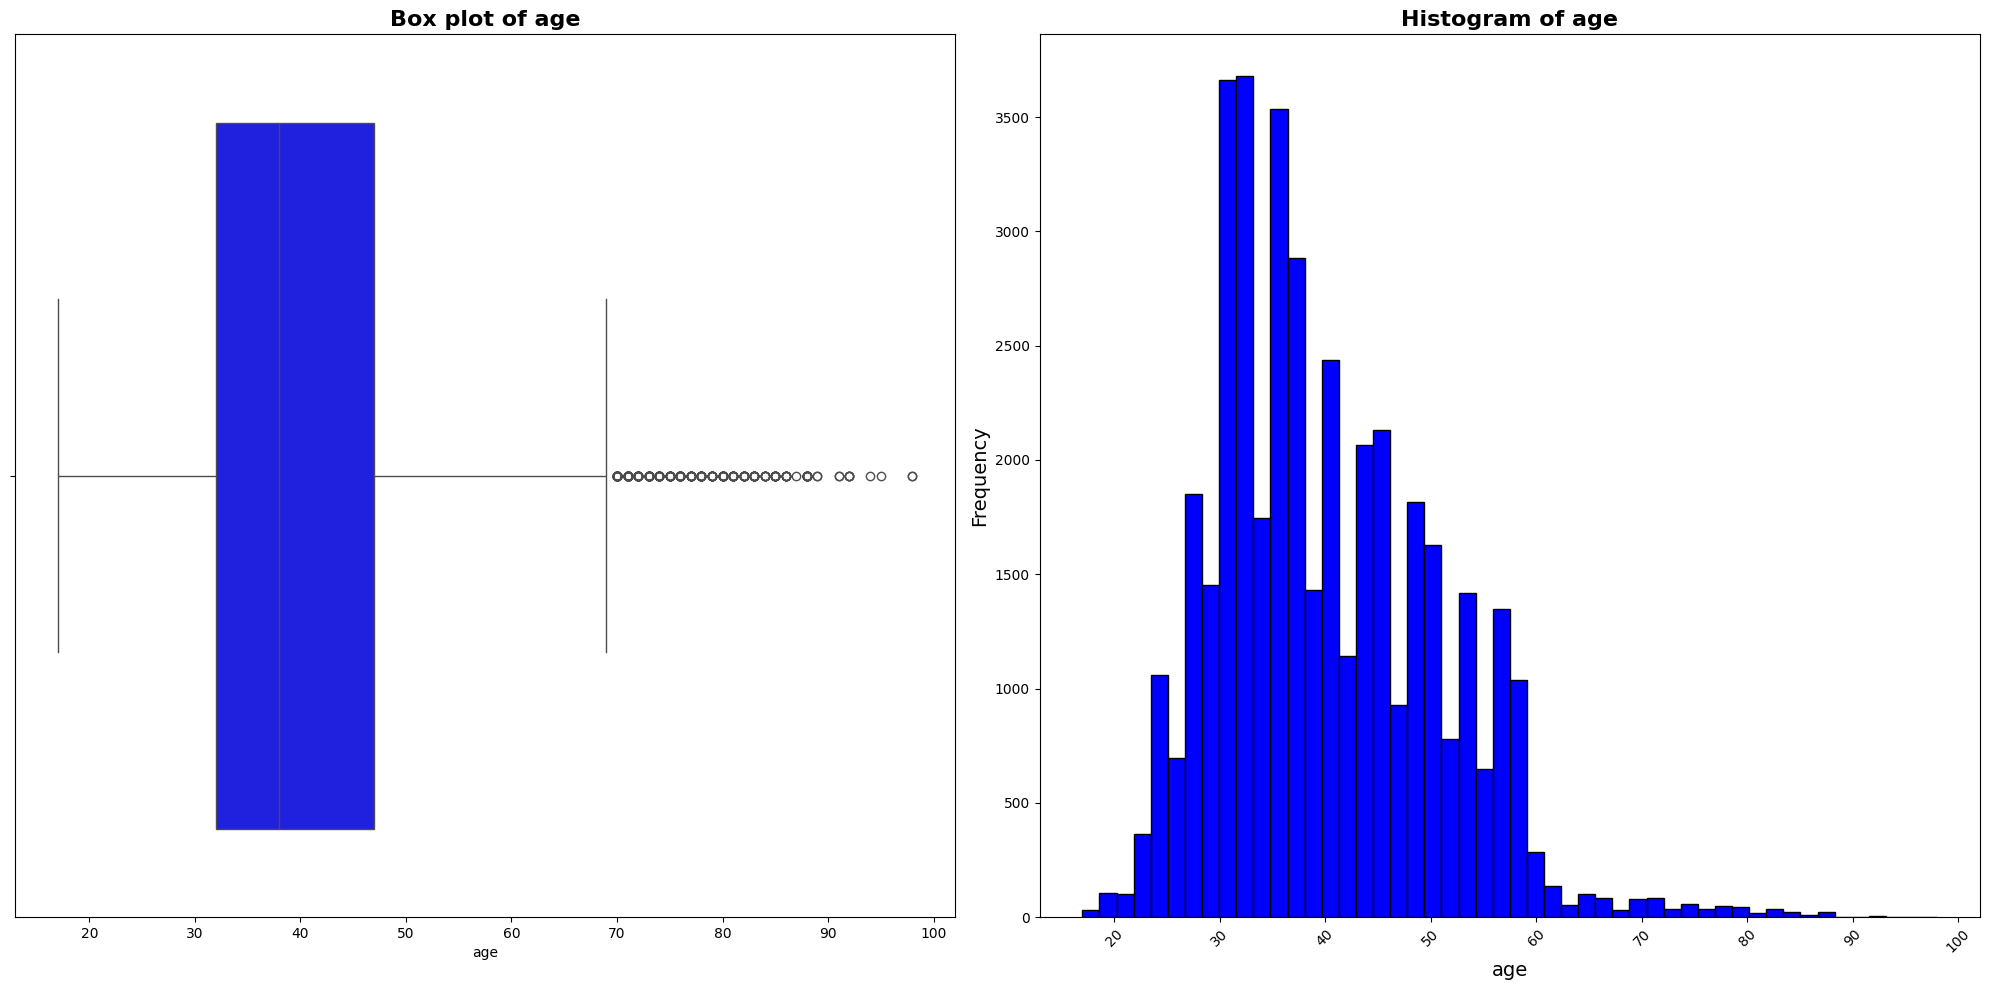

In [37]:
HelperFunctions.show_numeric_info(bank_df, 'age', 50)

As we can see, data can be considered normally distributed, if not the ages above 60.
But don't want to remove those ages, because it may reduce model accuracy and besides that, model which did ton train on data with ages above 60 can make wrong decisions.

***2. `job` column analysis***

count      41176
unique        12
top       admin.
freq       10419
Name: job, dtype: object
Number of null values: 0


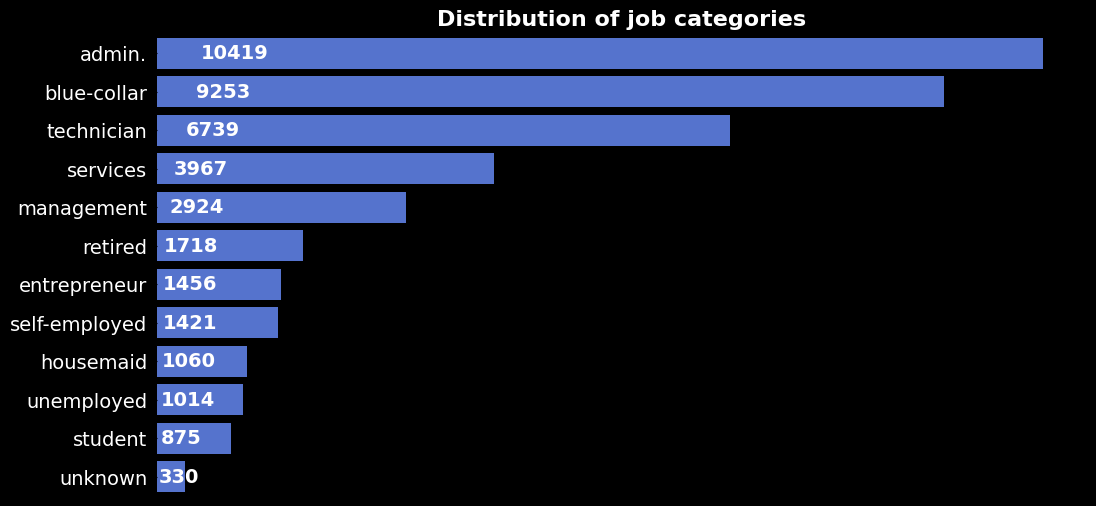

object


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [38]:
HelperFunctions.show_categorical_info(bank_df, 'job')

Here we can see, that there are not so many 'unknown' job types, so I would impute 'unknown' with mode value.

count      41176
unique        11
top       admin.
freq       10749
Name: job, dtype: object
Number of null values: 0


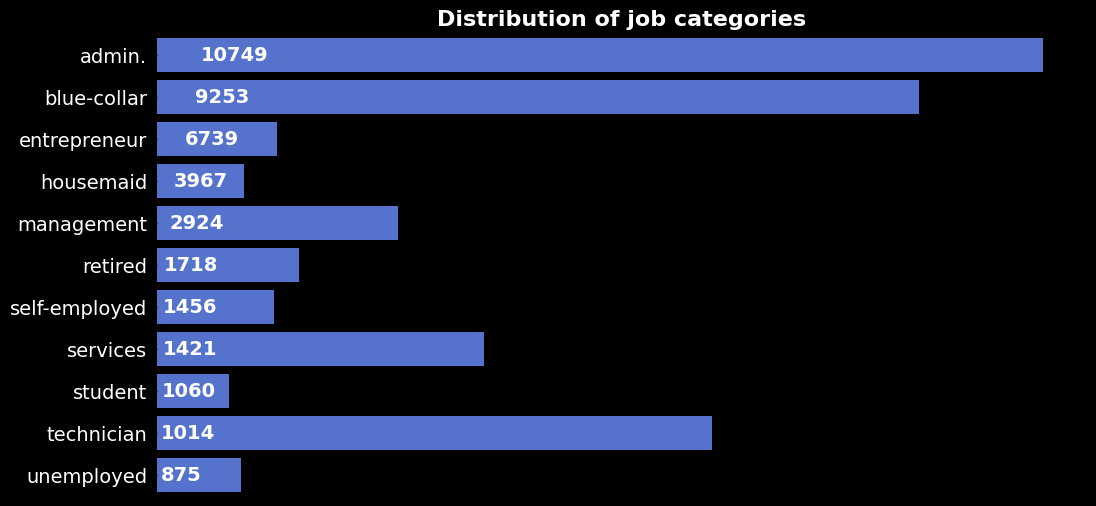

category


In [39]:
bank_df = HelperFunctions.impute_categorical_unknown_values(bank_df, 'job', 'mode')
HelperFunctions.show_categorical_info(bank_df, 'job')

***3. `marital` column analysis***

count       41176
unique          4
top       married
freq        24921
Name: marital, dtype: object
Number of null values: 0


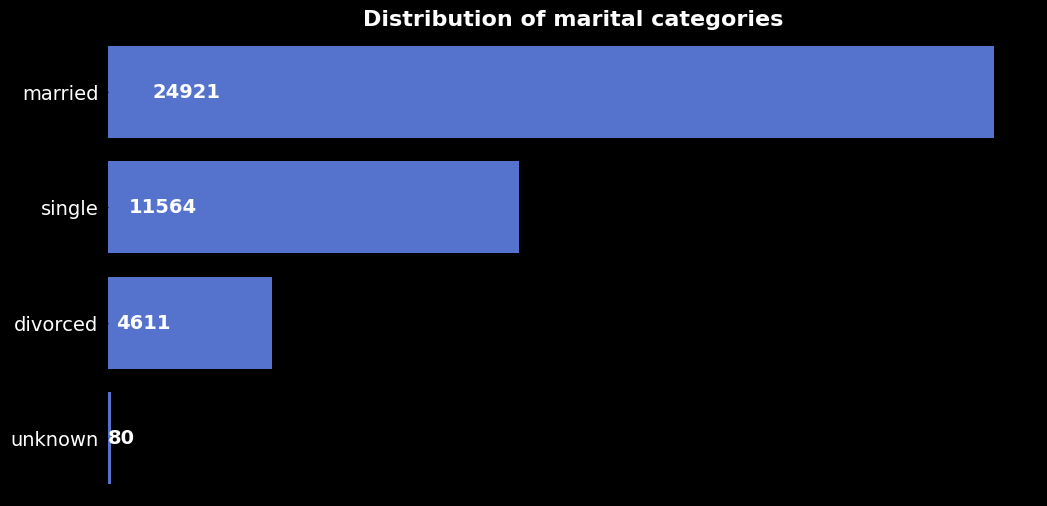

object


In [40]:
HelperFunctions.show_categorical_info(bank_df, 'marital')

Here also can se not so many 'unknown' marital status. So I would impute it wit most frequent category of a column.

count       41176
unique          3
top       married
freq        25001
Name: marital, dtype: object
Number of null values: 0


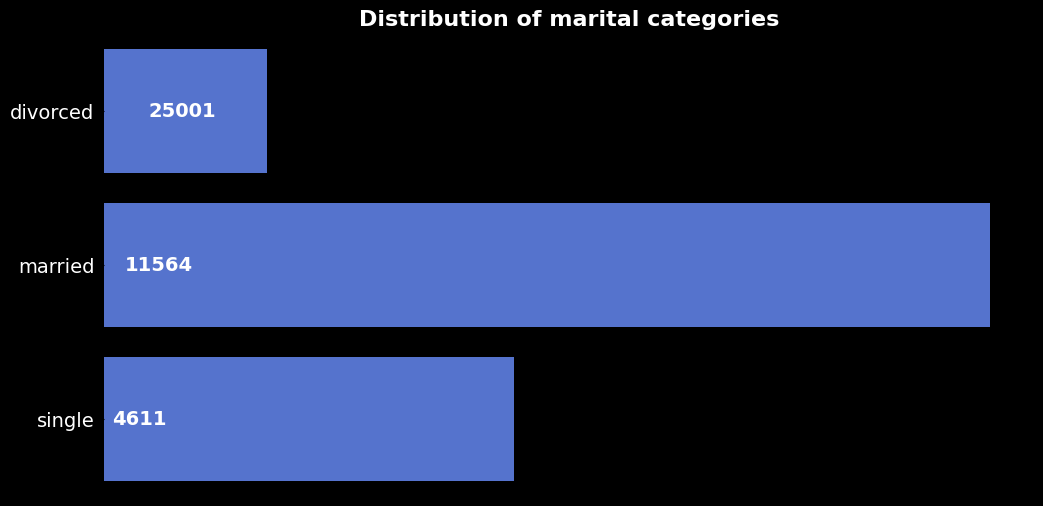

category


In [41]:
bank_df = HelperFunctions.impute_categorical_unknown_values(bank_df, 'marital', 'mode')
HelperFunctions.show_categorical_info(bank_df, 'marital')

***4. `education` column analysis***

count                 41176
unique                    8
top       university.degree
freq                  12164
Name: education, dtype: object
Number of null values: 0


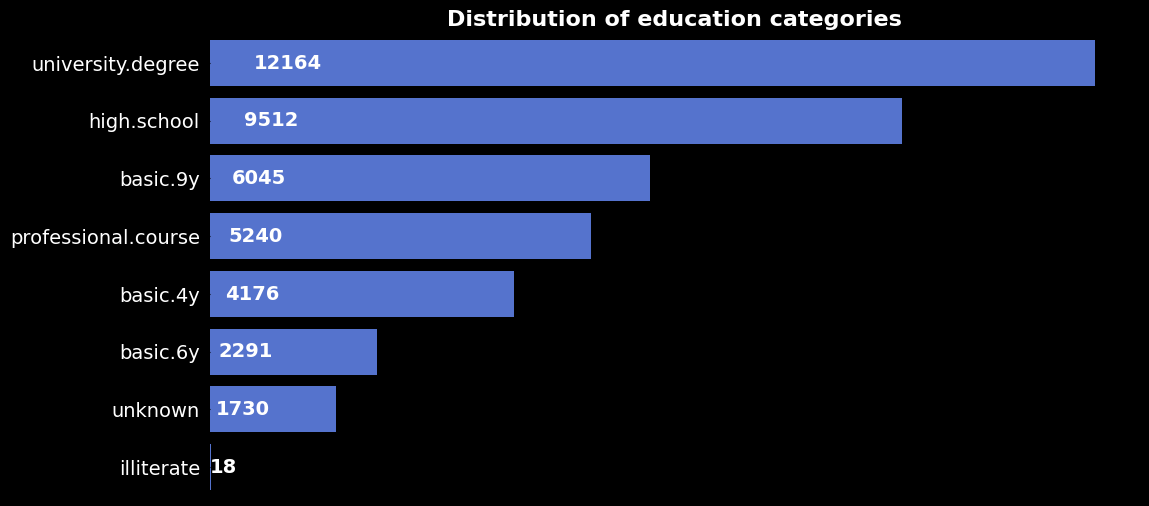

object


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [42]:
HelperFunctions.show_categorical_info(bank_df, 'education')

Here I see a little bit of unknown and no missing values, so imputation changes needed.

count                 41176
unique                    7
top       university.degree
freq                  13894
Name: education, dtype: object
Number of null values: 0


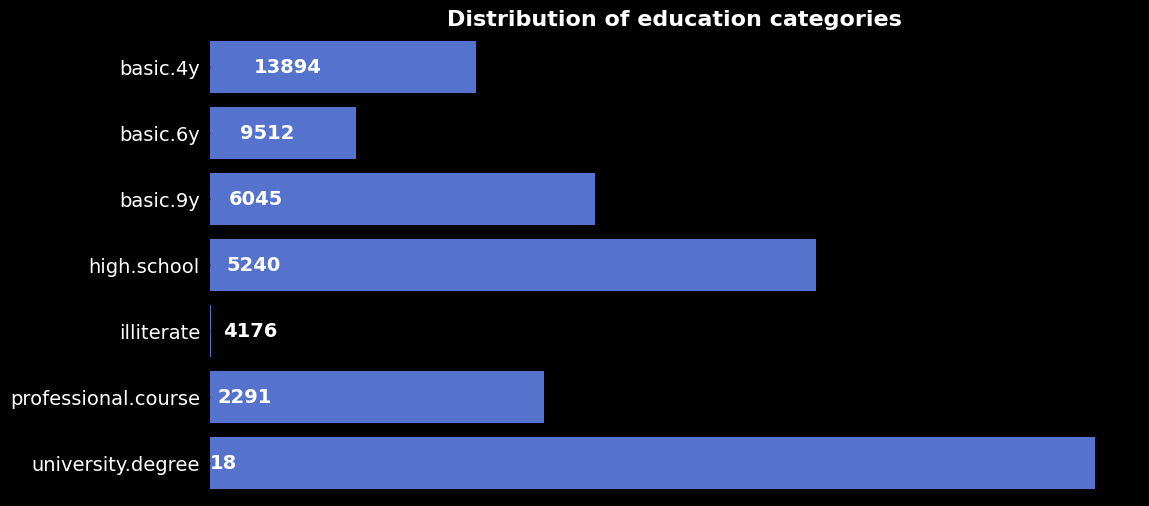

category


In [43]:
bank_df = HelperFunctions.impute_categorical_unknown_values(bank_df, 'education', 'mode')
HelperFunctions.show_categorical_info(bank_df, 'education')

***5. `default` column analysis***

count     41176
unique        3
top          no
freq      32577
Name: default, dtype: object
Number of null values: 0


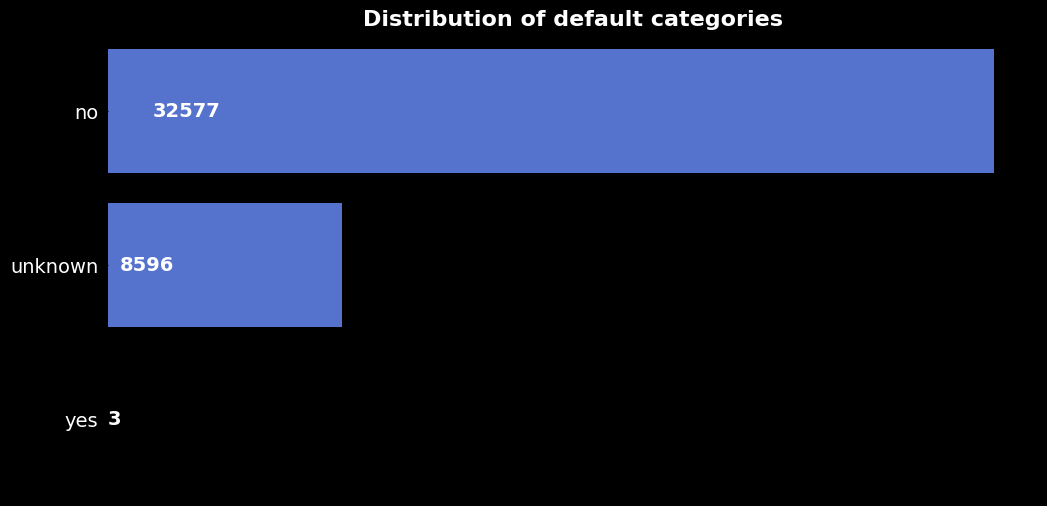

object


In [44]:
HelperFunctions.show_categorical_info(bank_df, 'default')

We can see there are many unknown rows. So I'll just transform this column into category type instead string to save memory as I don't sure whether should I transform unknown into yes or no.

count     41176
unique        3
top          no
freq      32577
Name: default, dtype: object
Number of null values: 0


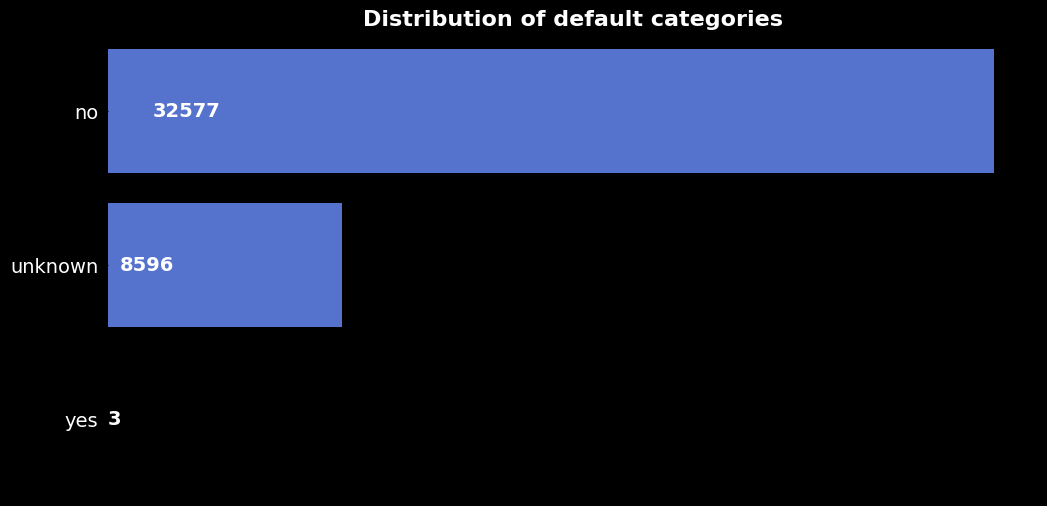

category


In [45]:
HelperFunctions.show_categorical_info(bank_df, 'default')

***6. `housing` column analysis***

count     41176
unique        3
top         yes
freq      21571
Name: housing, dtype: object
Number of null values: 0


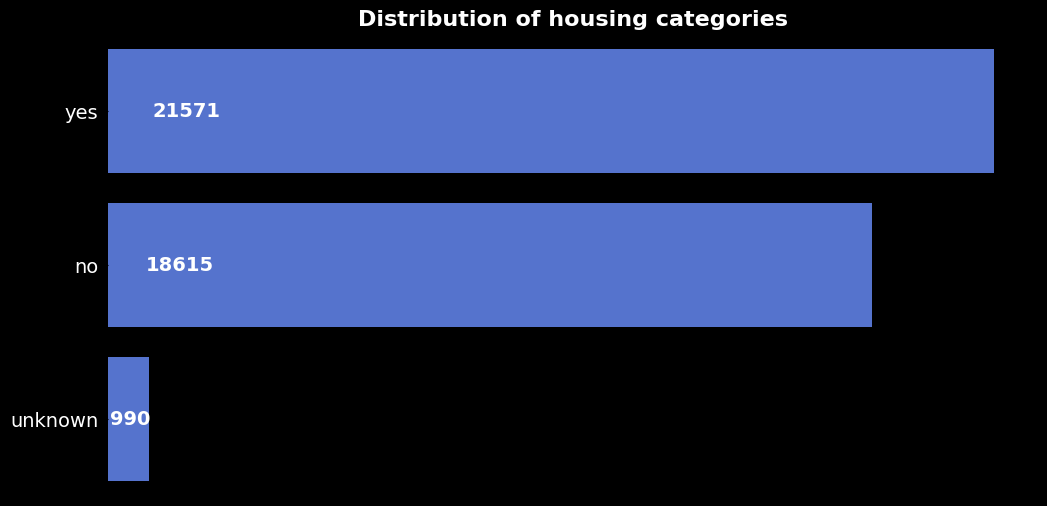

object


In [47]:
HelperFunctions.show_categorical_info(bank_df, 'housing')

Lets impute unknown with mode value here.

count     41176
unique        2
top         yes
freq      22561
Name: housing, dtype: object
Number of null values: 0


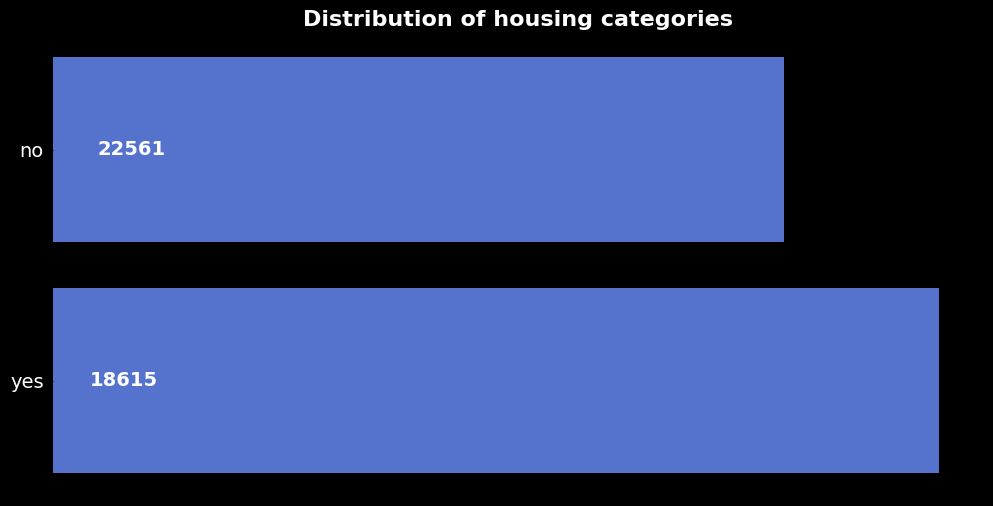

category


In [50]:
bank_df = HelperFunctions.impute_categorical_unknown_values(bank_df, 'housing', 'mode')
HelperFunctions.show_categorical_info(bank_df, 'housing')